## Dataset:
https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr

This dataset contains customer behavior and sales transaction data collected from an e-commerce platform. It includes customer demographics, product details, purchase information, payment methods, browsing behavior, delivery information, and customer ratings.

The dataset is suitable for tasks such as:

- Exploratory Data Analysis (EDA)
- Sales Prediction
- Customer Behavior Analysis
- Demand Forecasting
- Machine Learning
- Business Intelligence

In this project, the dataset is used to predict the **Total_Amount** of customer orders using supervised regression techniques.

Phân tích khám phá dữ liệu - EDA

Mục tiêu của bài lab này là tiến hành phân tích EDA dựa trên dữ liệu(ecommerce_customer_behavior_dataset_v2.csv). 

1.Tổng quan bộ dữ liệu (Dataset Overview)

Bước này đầu tiên tải thư viện, kiểm tra kích thước dữ dữ liệu và kiểu dữ liệu, xem trước 5 dòng dữ liệu đầu tiên

In [1]:
%pip install plotly

  Using cached plotly-6.8.0-py3-none-any.whl.metadata (9.0 kB)
Using cached plotly-6.8.0-py3-none-any.whl (9.9 MB)

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   ----------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")

# Đọc dữ liệu
df = pd.read_csv("../archive/ecommerce_customer_behavior_dataset_v2.csv")
 # Xem 5 dòng đầu
print(df.head())
# Kích thước dữ liệu
print( df.shape)

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Kiểu dữ liệu
df.info()      

<class 'pandas.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  str    
 1   Customer_ID               17049 non-null  str    
 2   Date                      17049 non-null  str    
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  str    
 5   City                      17049 non-null  str    
 6   Product_Category          17049 non-null  str    
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  str    
 12  Device_Type               17049 non-null  str    
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_Viewed     

In [ ]:
# Thống kê cơ bản cho các biến số (Age, Unit_Price, Total_Amount,...)
print("\n--- Thống kê mô tả (Biến số) ---")
display(df.describe())


--- Thống kê mô tả (Biến số) ---


,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000
mean,34.945745,447.901689,3.011379,69.788135,1277.438711,14.535633,9.003109,6.503607,3.899408
std,11.046855,722.319705,1.417027,240.704662,2358.436375,2.925524,2.259954,3.488787,1.128803
min,18.000000,5.050000,1.000000,0.000000,6.210000,4.000000,1.000000,1.000000,1.000000
25%,26.000000,73.260000,2.000000,0.000000,172.970000,13.000000,7.000000,4.000000,3.000000
50%,35.000000,174.680000,3.000000,0.000000,455.850000,15.000000,9.000000,6.000000,4.000000
75%,42.000000,494.570000,4.000000,32.710000,1267.750000,17.000000,11.000000,8.000000,5.000000
max,75.000000,7900.010000,5.000000,6538.290000,37852.050000,26.000000,18.000000,25.000000,5.000000


In [ ]:
# Thống kê cơ bản cho các biến phân loại (Gender, City, Product_Category,...)
print("\n--- Thống kê mô tả (Biến phân loại) ---")
display(df.describe(include=['object', 'bool']))


--- Thống kê mô tả (Biến phân loại) ---


C:\Users\PCPV\AppData\Local\Temp\ipykernel_22008\276759111.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['object', 'bool']))


,Order_ID,Customer_ID,Date,Gender,City,Product_Category,Payment_Method,Device_Type,Is_Returning_Customer
count,17049,17049,17049,17049,17049,17049,17049,17049,17049
unique,17049,5000,450,3,10,8,5,3,2
top,ORD_000001-1,CUST_00016,2023-07-29,Female,Istanbul,Sports,Credit Card,Mobile,True
freq,1,10,59,8613,4402,2248,6801,9543,15039


2. Phân tích dữ liệu thiếu (Missing Value Analysis)
   


--- Phân tích dữ liệu thiếu ---


,Số lượng thiếu,Tỷ lệ thiếu (%)


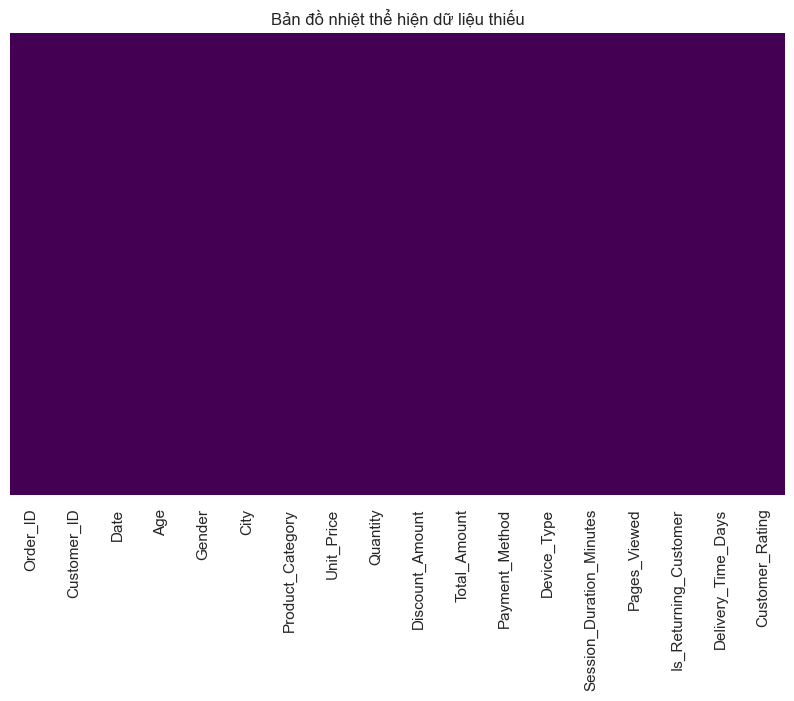

In [ ]:
# Phát hiện số lượng và tỷ lệ giá trị bị thiếu
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Số lượng thiếu': missing_data, 'Tỷ lệ thiếu (%)': missing_percent})
print("\n--- Phân tích dữ liệu thiếu ---")
display(missing_df[missing_df['Số lượng thiếu'] > 0])

# Trực quan hóa quy luật thiếu dữ liệu bằng Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Bản đồ nhiệt thể hiện dữ liệu thiếu')
plt.show()

 3. Phân tích đơn biến (Univariate Analysis)

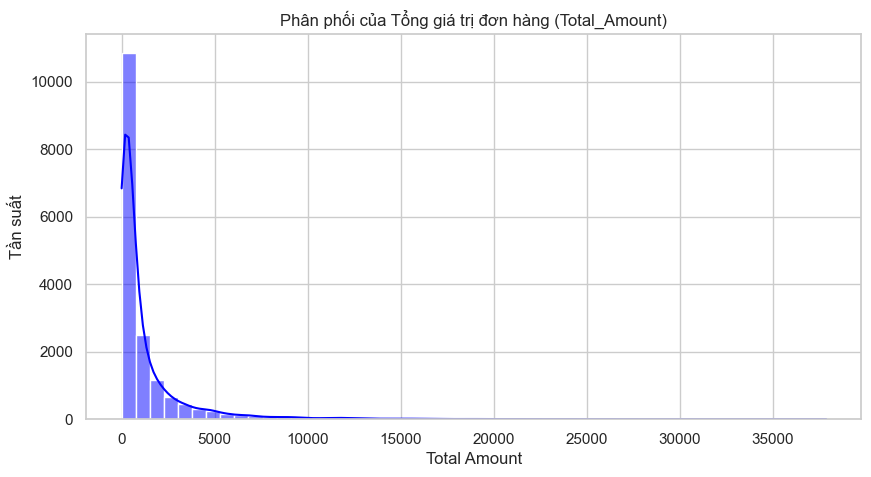

In [ ]:
# Biểu đồ phân phối (Histogram) cho Total_Amount
plt.figure(figsize=(10, 5))
sns.histplot(df['Total_Amount'], bins=50, kde=True, color='blue')
plt.title('Phân phối của Tổng giá trị đơn hàng (Total_Amount)')
plt.xlabel('Total Amount')
plt.ylabel('Tần suất')
plt.show()


In [ ]:
# Kiểm tra độ lệch phân phối (Skewness)

skewness = df["Total_Amount"].skew()

print("Skewness của Total_Amount:", round(skewness, 3))

Skewness của Total_Amount: 4.585


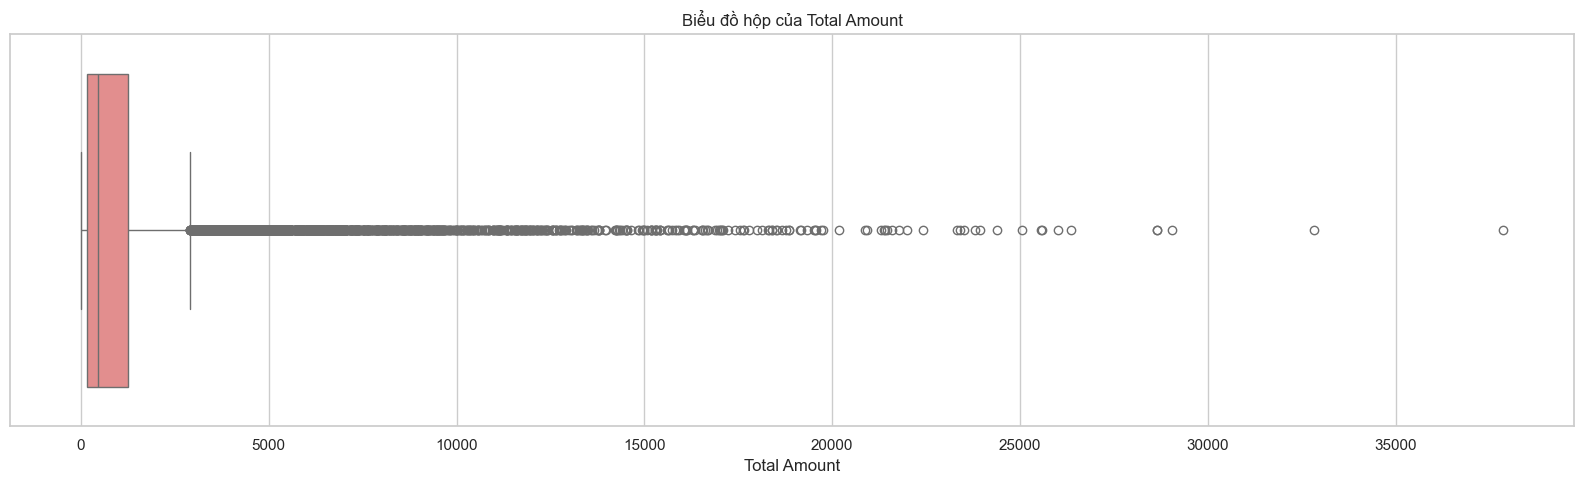

In [ ]:
axes = plt.subplots(1, figsize=(16, 5))
# Biểu đồ Boxplot để xem phân phối và đuôi ngoại lệ
sns.boxplot(x=df['Total_Amount'], ax=axes[1], color='lightcoral')
axes[1].set_title('Biểu đồ hộp của Total Amount')
axes[1].set_xlabel('Total Amount')

plt.tight_layout()
plt.show()

C:\Users\PCPV\AppData\Local\Temp\ipykernel_22008\2785842158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Product_Category', order=df['Product_Category'].value_counts().index, palette='Set2')


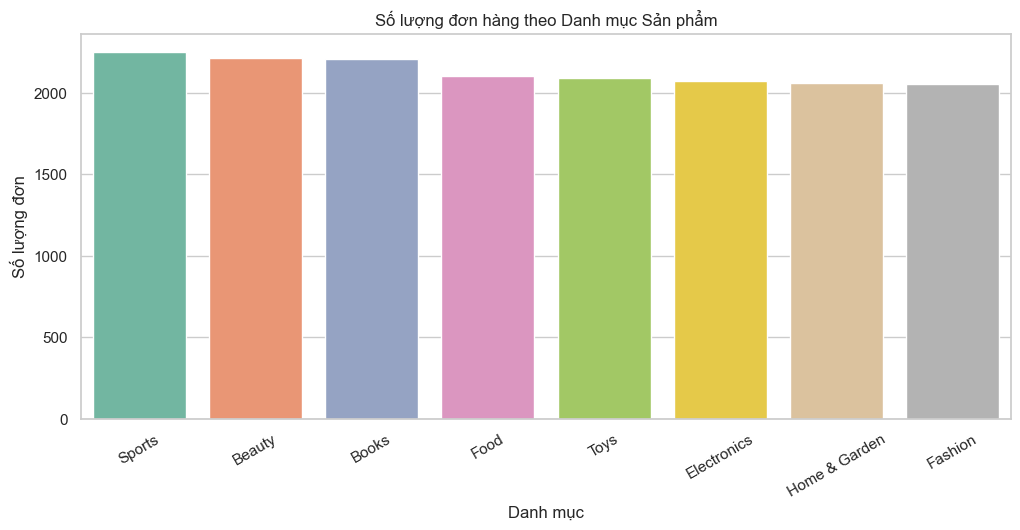

In [ ]:
#Biến phân loại: Tần suất của Danh mục sản phẩm (Product_Category)
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Product_Category', order=df['Product_Category'].value_counts().index, palette='Set2')
plt.title('Số lượng đơn hàng theo Danh mục Sản phẩm')
plt.xlabel('Danh mục')
plt.ylabel('Số lượng đơn')
plt.xticks(rotation=30)
plt.show()

4. Phân tích hai biến và đa biến (Bivariate and Multivariate Analysis)

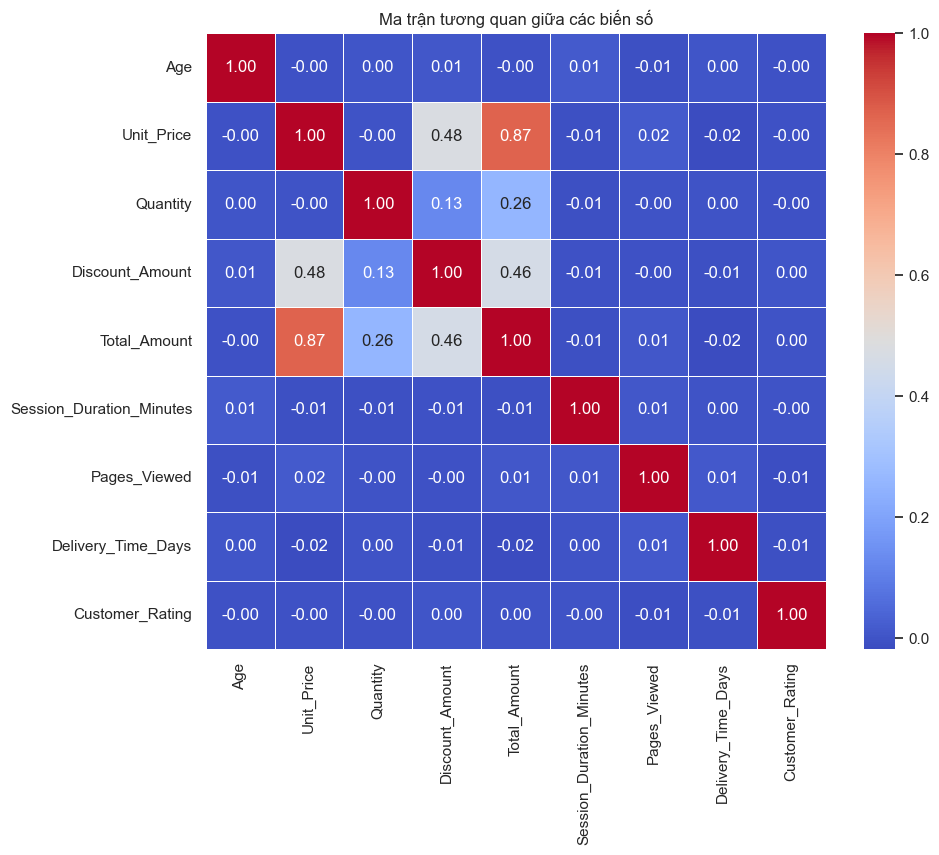

C:\Users\PCPV\AppData\Local\Temp\ipykernel_22008\511300331.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product_Category', y='Total_Amount', palette='Pastel1')


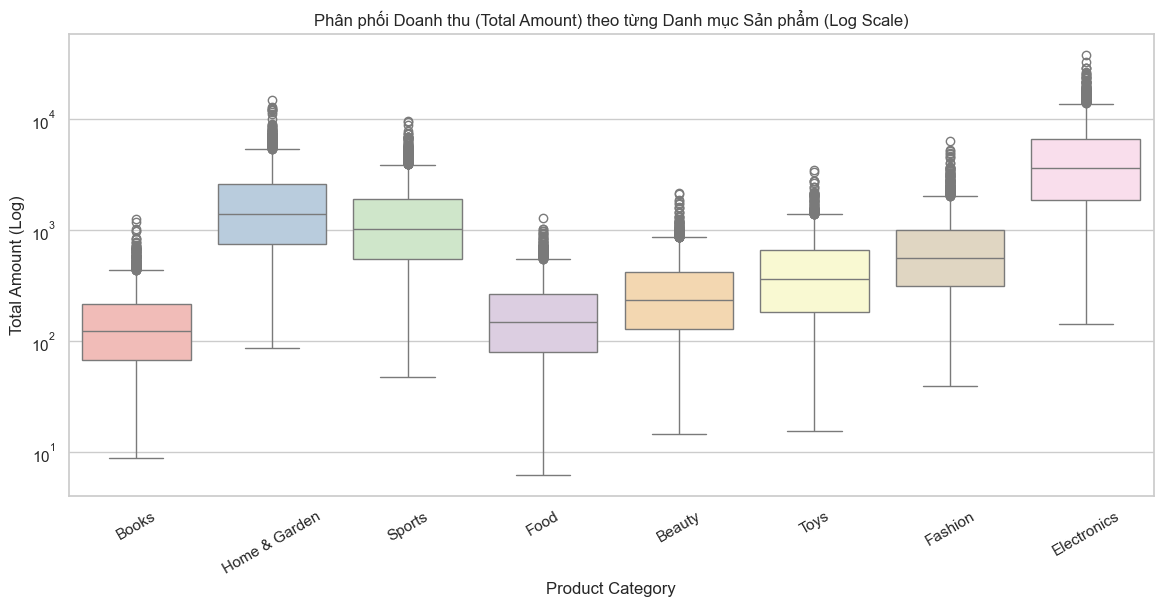

--- Bảng chéo (Contingency Table) ---
Device_Type       Desktop  Mobile  Tablet
Payment_Method                           
Bank Transfer         593    1009     161
Cash on Delivery      342     456      90
Credit Card          2323    3807     671
Debit Card           1435    2458     428
Digital Wallet       1152    1813     311

Kiểm định Chi-Square - p-value: 0.1089


In [ ]:
# 4.1 Biến số với Biến số: Ma trận tương quan
numerical_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 8))
# Sử dụng phương pháp Pearson để tính tương quan tuyến tính
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

# 4.2 Biến phân loại với Biến số: Doanh thu (Total_Amount) theo Danh mục (Product_Category)
plt.figure(figsize=(14, 6))
# Sử dụng log scale cho trục Y vì Total_Amount có biên độ dao động cực lớn (từ 6 đến hơn 37,000)
sns.boxplot(data=df, x='Product_Category', y='Total_Amount', palette='Pastel1')
plt.yscale('log') 
plt.title('Phân phối Doanh thu (Total Amount) theo từng Danh mục Sản phẩm (Log Scale)')
plt.xticks(rotation=30)
plt.xlabel('Product Category')
plt.ylabel('Total Amount (Log)')
plt.show()

# 4.3 Biến phân loại với Biến phân loại: Bảng chéo giữa Phương thức thanh toán và Thiết bị mua hàng
contingency_table = pd.crosstab(df['Payment_Method'], df['Device_Type'])
print("--- Bảng chéo (Contingency Table) ---")
print(contingency_table)

# Kiểm định Chi-square
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"\nKiểm định Chi-Square - p-value: {p:.4f}")

5. Phát hiện ngoại lệ (Outlier Detection)

In [ ]:
# Tính toán ngoại lệ dựa trên IQR cho cột Total_Amount
Q1 = df['Total_Amount'].quantile(0.25)
Q3 = df['Total_Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Total_Amount'] < lower_bound) | (df['Total_Amount'] > upper_bound)]

print(f"Giới hạn dưới (Lower Bound): {lower_bound:.2f}")
print(f"Giới hạn trên (Upper Bound): {upper_bound:.2f}")
print(f"Số lượng dòng bị coi là ngoại lệ: {len(outliers)} dòng")
print(f"Tỷ lệ ngoại lệ trong bộ dữ liệu: {len(outliers) / len(df) * 100:.2f}%")

# Hiển thị thử một số dòng dữ liệu ngoại lệ cao nhất
print("\n--- Top 5 đơn hàng có Total_Amount ngoại lệ cao nhất ---")
print(outliers[['Order_ID', 'Product_Category', 'Unit_Price', 'Quantity', 'Total_Amount']].sort_values(by='Total_Amount', ascending=False).head())

Giới hạn dưới (Lower Bound): -1469.20
Giới hạn trên (Upper Bound): 2909.92
Số lượng dòng bị coi là ngoại lệ: 1943 dòng
Tỷ lệ ngoại lệ trong bộ dữ liệu: 11.40%

--- Top 5 đơn hàng có Total_Amount ngoại lệ cao nhất ---
           Order_ID Product_Category  Unit_Price  Quantity  Total_Amount
12862  ORD_003795-1      Electronics     7570.41         5      37852.05
13247  ORD_003906-5      Electronics     7440.42         5      32823.53
10483  ORD_003084-1      Electronics     5809.07         5      29045.35
5451   ORD_001573-2      Electronics     5728.15         5      28640.75
10732  ORD_003149-5      Electronics     6598.67         5      28638.86


Feature Engineering Guide - Predicting Product Sales

1. Feature Engineering Overview
* Mục tiêu: Chuẩn bị, biến đổi dữ liệu thô thành tập dữ liệu số hóa, chuẩn hóa phù hợp cho các mô hình Regression (Hồi quy) dự đoán `Total_Amount`.
* Kiểm tra tổng quan cấu trúc dữ liệu hiện tại trước khi xử lý.

In [ ]:
# Xem kích thước ma trận dữ liệu hiện tại
print(f"Cấu trúc dữ liệu hiện tại: {df.shape[0]} dòng, {df.shape[1]} cột.\n")

# Kiểm tra tổng quan các cột và kiểu dữ liệu (DType) ban đầu
print("--- Danh sách các cột và kiểu dữ liệu gốc ---")
print(df.info())

# Hiển thị 5 dòng đầu tiên để xem hình thái dữ liệu thô
df.head()

Cấu trúc dữ liệu hiện tại: 17049 dòng, 18 cột.

--- Danh sách các cột và kiểu dữ liệu gốc ---
<class 'pandas.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  str    
 1   Customer_ID               17049 non-null  str    
 2   Date                      17049 non-null  str    
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  str    
 5   City                      17049 non-null  str    
 6   Product_Category          17049 non-null  str    
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  str    
 12  Device_Type               17049 n

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


## 2. Feature Selection

Feature Selection is the process of identifying the most relevant variables for predicting the target variable.

In [ ]:
# 1. Định nghĩa danh sách các đặc trưng đầu vào (Input Features) theo hướng dẫn
selected_features = [
    'Age', 'Gender', 'City', 'Product_Category', 'Unit_Price', 'Quantity', 
    'Discount_Amount', 'Payment_Method', 'Device_Type', 'Session_Duration_Minutes', 
    'Pages_Viewed', 'Is_Returning_Customer', 'Delivery_Time_Days', 'Customer_Rating',
    'Date' # Giữ lại cột Date để làm nguyên liệu tách thời gian ở mục 3
]

# 2. Định nghĩa biến mục tiêu (Target)
target_variable = 'Total_Amount'

# 3. Tiến hành lọc và chỉ giữ lại các cột cần thiết trong DataFrame
df_selected = df[selected_features + [target_variable]].copy()

# 4. Kiểm tra lại kết quả lọc dữ liệu
print(f"Kích thước tập dữ liệu cũ: {df.shape}")
print(f"Kích thước tập dữ liệu sau khi loại bỏ ID (Feature Selection): {df_selected.shape}")
print("\nCác cột dữ liệu được giữ lại:")
print(df_selected.columns.tolist())

Kích thước tập dữ liệu cũ: (17049, 18)
Kích thước tập dữ liệu sau khi loại bỏ ID (Feature Selection): (17049, 16)

Các cột dữ liệu được giữ lại:
['Age', 'Gender', 'City', 'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Payment_Method', 'Device_Type', 'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer', 'Delivery_Time_Days', 'Customer_Rating', 'Date', 'Total_Amount']


## 3. Data Type Transformation

Data type transformation ensures that every feature has the appropriate data type before further preprocessing.

3.1 Datetime Conversion

In [ ]:
import pandas as pd

# 1. Kiểm tra kiểu dữ liệu của cột Date trước khi biến đổi
print("Kiểu dữ liệu gốc của cột Date:", df_selected['Date'].dtype)

# 2. Tiến hành chuyển đổi sang định dạng datetime chuẩn của Pandas
df_selected['Date'] = pd.to_datetime(df_selected['Date'])

# 3. Trích xuất các đặc trưng thời gian (Feature Extraction)
df_selected['Year'] = df_selected['Date'].dt.year
df_selected['Month'] = df_selected['Date'].dt.month
df_selected['Day'] = df_selected['Date'].dt.day
df_selected['DayOfWeek'] = df_selected['Date'].dt.dayofweek  # 0 = Thứ 2, 6 = Chủ Nhật

# 4. Xác nhận lại kiểu dữ liệu sau khi biến đổi thành công
print("Kiểu dữ liệu sau khi xử lý:")
print(df_selected[['Date', 'Year', 'Month', 'Day', 'DayOfWeek']].dtypes)

# 5. Hiển thị 5 dòng đầu tiên để kiểm tra trực quan
df_selected[['Date', 'Year', 'Month', 'Day', 'DayOfWeek']].head()

Kiểu dữ liệu gốc của cột Date: datetime64[us]
Kiểu dữ liệu sau khi xử lý:
Date         datetime64[us]
Year                  int32
Month                 int32
Day                   int32
DayOfWeek             int32
dtype: object


,Date,Year,Month,Day,DayOfWeek
0,2023-05-29,2023,5,29,0
1,2023-10-12,2023,10,12,3
2,2023-12-05,2023,12,5,1
3,2023-05-11,2023,5,11,3
4,2023-06-16,2023,6,16,4


3.2 Categorical Type Conversion

In [ ]:
# 1. Định nghĩa danh sách các biến phân loại dạng chuỗi text
categorical_features = ['Gender', 'City', 'Product_Category', 'Payment_Method', 'Device_Type']

# 2. Thực hiện ép kiểu sang 'category' bằng vòng lặp
for col in categorical_features:
    df_selected[col] = df_selected[col].astype('category')

# 3. Ép kiểu cho cột mang tính logic nhị phân sang định dạng Boolean (True/False)
df_selected['Is_Returning_Customer'] = df_selected['Is_Returning_Customer'].astype('bool')

# 4. Kiểm tra lại thông tin kiểu dữ liệu (Dtype) để xác nhận hệ thống đã nhận diện chính xác
print("--- Kiểm tra kiểu dữ liệu sau khi ép kiểu phân loại ---")
print(df_selected[categorical_features + ['Is_Returning_Customer']].dtypes)

# 5. Hiển thị thông số tóm tắt của các biến danh mục để kiểm tra số nhóm (Categories)
print("\n--- Tóm tắt các biến danh mục ---")
df_selected[categorical_features].describe()

--- Kiểm tra kiểu dữ liệu sau khi ép kiểu phân loại ---
Gender                   category
City                     category
Product_Category         category
Payment_Method           category
Device_Type              category
Is_Returning_Customer        bool
dtype: object

--- Tóm tắt các biến danh mục ---


,Gender,City,Product_Category,Payment_Method,Device_Type
count,17049,17049,17049,17049,17049
unique,3,10,8,5,3
top,Female,Istanbul,Sports,Credit Card,Mobile
freq,8613,4402,2248,6801,9543


3.3 Numerical Type Validation

In [ ]:
# 1. Định nghĩa danh sách các thuộc tính dạng số cần kiểm tra
numerical_features = [
    'Age', 'Unit_Price', 'Quantity', 'Discount_Amount', 
    'Session_Duration_Minutes', 'Pages_Viewed', 
    'Delivery_Time_Days', 'Customer_Rating'
]

# 2. Vòng lặp kiểm tra và ép kiểu số ép buộc (to_numeric với errors='coerce')
# Nếu gặp ký tự lạ, lỗi sẽ tự động chuyển thành NaN thay vì làm sập chương trình
for col in numerical_features:
    df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')

# 3. Kiểm tra xem có cột nào vô tình phát sinh giá trị khuyết thiếu (NaN) sau khi ép kiểu không
missing_after_validation = df_selected[numerical_features].isnull().sum()

print("--- Số lượng giá trị trống (NaN) phát sinh sau khi xác thực kiểu số ---")
print(missing_after_validation)

# 4. Xác nhận lại kiểu dữ liệu (Dtype) chuẩn của các cột số
print("\n--- Kiểu dữ liệu chính thức của các cột số ---")
print(df_selected[numerical_features].dtypes)

# 5. Hiển thị thống kê mô tả nhanh để xem phân phối số liệu đã hợp lý chưa
df_selected[numerical_features].describe()

--- Số lượng giá trị trống (NaN) phát sinh sau khi xác thực kiểu số ---
Age                         0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Session_Duration_Minutes    0
Pages_Viewed                0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

--- Kiểu dữ liệu chính thức của các cột số ---
Age                           int64
Unit_Price                  float64
Quantity                      int64
Discount_Amount             float64
Session_Duration_Minutes      int64
Pages_Viewed                  int64
Delivery_Time_Days            int64
Customer_Rating               int64
dtype: object


,Age,Unit_Price,Quantity,Discount_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000
mean,34.945745,447.901689,3.011379,69.788135,14.535633,9.003109,6.503607,3.899408
std,11.046855,722.319705,1.417027,240.704662,2.925524,2.259954,3.488787,1.128803
min,18.000000,5.050000,1.000000,0.000000,4.000000,1.000000,1.000000,1.000000
25%,26.000000,73.260000,2.000000,0.000000,13.000000,7.000000,4.000000,3.000000
50%,35.000000,174.680000,3.000000,0.000000,15.000000,9.000000,6.000000,4.000000
75%,42.000000,494.570000,4.000000,32.710000,17.000000,11.000000,8.000000,5.000000
max,75.000000,7900.010000,5.000000,6538.290000,26.000000,18.000000,25.000000,5.000000


3.4 Data Type Consistency

In [ ]:
# 1. Lấy danh sách các cột dạng 'object' còn sót lại (loại trừ cột 'Date')
object_cols = df_selected.select_dtypes(include=['object']).columns.tolist()
if 'Date' in object_cols:
    object_cols.remove('Date')

# 2. In bảng thống kê kiểm tra tính nhất quán
print("=== BÁO CÁO RÀ SOÁT TÍNH NHẤT QUÁN KIỂU DỮ LIỆU ===")
print(f"Tổng số cột hiện tại: {len(df_selected.columns)}")
print(f"-> Số cột dạng Số (Numerical): {len(df_selected.select_dtypes(include=['number']).columns)}")
print(f"-> Số cột dạng Danh mục (Categorical): {len(df_selected.select_dtypes(include=['category']).columns)}")
print(f"-> Số cột dạng Logic (Boolean): {len(df_selected.select_dtypes(include=['bool']).columns)}")
print(f"-> Số cột dạng Thời gian (Datetime): {len(df_selected.select_dtypes(include=['datetime64']).columns)}")

print("\n--------------------------------------------------")
# 3. Đưa ra cảnh báo tự động nếu phát hiện dữ liệu chưa nhất quán
if len(object_cols) > 0:
    print(f"⚠️ CẢNH BÁO: Còn {len(object_cols)} cột chưa được số hóa hoặc phân loại chuẩn: {object_cols}")
    print("Mẹo: Hãy kiểm tra lại bước 3.2 hoặc 3.3 để ép kiểu cho các cột này.")
else:
    print("✅ XÁC NHẬN: Toàn bộ kiểu dữ liệu đã nhất quán hoàn hảo! Sẵn sàng chuyển sang bước mã hóa (Encoding).")

# 4. Hiển thị nhanh 3 dòng đầu để kiểm tra hình thái dữ liệu trực quan lần cuối
df_selected.head(3)

=== BÁO CÁO RÀ SOÁT TÍNH NHẤT QUÁN KIỂU DỮ LIỆU ===
Tổng số cột hiện tại: 20
-> Số cột dạng Số (Numerical): 13
-> Số cột dạng Danh mục (Categorical): 5
-> Số cột dạng Logic (Boolean): 1
-> Số cột dạng Thời gian (Datetime): 1

--------------------------------------------------
✅ XÁC NHẬN: Toàn bộ kiểu dữ liệu đã nhất quán hoàn hảo! Sẵn sàng chuyển sang bước mã hóa (Encoding).


,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Date,Total_Amount,Year,Month,Day,DayOfWeek
0,40,Male,Ankara,Books,29.18,1,0.00,Digital Wallet,Mobile,14,9,True,13,4,2023-05-29,29.18,2023,5,29,0
1,40,Male,Ankara,Home & Garden,644.40,1,138.05,Credit Card,Desktop,14,8,True,6,2,2023-10-12,506.35,2023,10,12,3
2,40,Male,Ankara,Sports,332.82,5,0.00,Credit Card,Mobile,15,10,True,9,4,2023-12-05,1664.10,2023,12,5,1


## 4. Categorical Feature Encoding
* **Mục tiêu:** Chuyển đổi các biến định tính (Categorical Variables) thành các đại diện số học (Numerical Representations) vì thuật toán Machine Learning chỉ có thể tính toán trên các ma trận số.
* **Chiến lược mã hóa toán học:**
  * **Label Encoding:** Áp dụng cho biến nhị phân hoặc biến ít nhóm như `Gender` (Male/Female/Other) và `Device_Type` (Mobile/Desktop/Tablet). Phương pháp này gán mỗi nhóm thành một số nguyên (0, 1, 2...).
  * **One-Hot Encoding (Dummification):** Áp dụng cho các biến nhiều nhóm, không mang tính thứ tự như `City`, `Product_Category`, và `Payment_Method`. Phương pháp này tạo ra các cột nhị phân bổ sung (0 hoặc 1) để tránh việc mô hình hiểu nhầm các con số có thứ tự lớn bé.

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Tạo một bản sao DataFrame mới chuyên biệt cho giai đoạn Encoding
df_encoded = df_selected.copy()

# 2. Áp dụng LABEL ENCODING cho các biến ít danh mục (Gender, Device_Type)
label_cols = ['Gender', 'Device_Type']
le = LabelEncoder()

for col in label_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"-> Đã mã hóa Label Encoding cho cột '{col}'. Các lớp nhãn tương ứng: {list(le.classes_)}")

# 3. Áp dụng ONE-HOT ENCODING cho các biến nhiều danh mục (City, Product_Category, Payment_Method)
# Sử dụng drop_first=True để loại bỏ cột đầu tiên (tránh hiện tượng đa cộng tuyến - Multicollinearity trong Regression)
one_hot_cols = ['City', 'Product_Category', 'Payment_Method']
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=True)

# 4. Kiểm tra sự thay đổi về kích thước ma trận dữ liệu và định dạng cột
print("\n------------------------------------------------------------")
print(f"Kích thước tập dữ liệu trước khi Encoding: {df_selected.shape}")
print(f"Kích thước tập dữ liệu sau khi Encoding: {df_encoded.shape}")
print("\n--- Danh sách kiểu dữ liệu của các cột mới sau khi Encoding ---")
print(df_encoded.dtypes.head(20)) # Hiển thị 20 cột đầu tiên để kiểm tra thử

-> Đã mã hóa Label Encoding cho cột 'Gender'. Các lớp nhãn tương ứng: ['Female', 'Male', 'Other']
-> Đã mã hóa Label Encoding cho cột 'Device_Type'. Các lớp nhãn tương ứng: ['Desktop', 'Mobile', 'Tablet']

------------------------------------------------------------
Kích thước tập dữ liệu trước khi Encoding: (17049, 20)
Kích thước tập dữ liệu sau khi Encoding: (17049, 37)

--- Danh sách kiểu dữ liệu của các cột mới sau khi Encoding ---
Age                                  int64
Gender                               int64
Unit_Price                         float64
Quantity                             int64
Discount_Amount                    float64
Device_Type                          int64
Session_Duration_Minutes             int64
Pages_Viewed                         int64
Is_Returning_Customer                 bool
Delivery_Time_Days                   int64
Customer_Rating                      int64
Date                        datetime64[us]
Total_Amount                       float64
Y

## 5. Feature Scaling (Chuẩn hóa đặc trưng số)
* **Mục tiêu:** Đưa các biến số (Numerical Features) về cùng một thang đo (Scale) tương đương.
* **Tại sao cần làm?** Các biến như `Unit_Price` có giá trị lên tới hàng nghìn, trong khi `Quantity` chỉ từ 1-5 hay `Customer_Rating` từ 1-5. Nếu không chuẩn hóa, các biến có biên độ lớn sẽ "áp đảo" các biến nhỏ, làm giảm hiệu suất của các thuật toán (như Tuyến tính, KNN, SVM, hay Mạng nơ-ron).
* **Kỹ thuật lựa chọn:** Sử dụng **StandardScaler** (Z-score normalization). Kỹ thuật này biến đổi dữ liệu sao cho giá trị trung bình (mean) bằng 0 và độ lệch chuẩn (standard deviation) bằng 1.
* **Lưu ý:** Biến mục tiêu (`Total_Amount`) **không** thực hiện chuẩn hóa để giữ nguyên giá trị thực tế cho việc đánh giá sai số mô hình sau này.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Tạo một bản sao DataFrame chuyên biệt cho giai đoạn Scaling từ dữ liệu sau mã hóa ở bước 4
df_scaled = df_encoded.copy()

# 2. Định nghĩa danh sách các thuộc tính số cần được chuẩn hóa theo hướng dẫn
scaled_features = [
    'Age', 'Unit_Price', 'Quantity', 'Discount_Amount', 
    'Session_Duration_Minutes', 'Pages_Viewed', 
    'Delivery_Time_Days', 'Customer_Rating'
]

# Thêm cả các đặc trưng thời gian (Year, Month, Day, DayOfWeek) vừa tạo ở mục 3 nếu muốn mô hình học mượt hơn
# Tuy nhiên, theo đúng chuẩn tài liệu, ta tập trung vào 8 đặc trưng cốt lõi trên trước.

# 3. Khởi tạo công cụ StandardScaler
scaler = StandardScaler()

# 4. Áp dụng chuẩn hóa (Fit và Transform) lên các cột số đã chọn
df_scaled[scaled_features] = scaler.fit_transform(df_scaled[scaled_features])

# 5. Kiểm tra kết quả sau khi chuẩn hóa (Mean sấp sỉ 0, Std bằng 1)
print("=== KIỂM TRA ĐẶC TRƯNG SAU KHI CHUẨN HÓA (FEATURE SCALING) ===")
print(df_scaled[scaled_features].describe().loc[['mean', 'std', 'min', 'max']])

# 6. Xác nhận biến mục tiêu Total_Amount không bị thay đổi scale
print("\n------------------------------------------------------------")
print("Giá trị trung bình gốc của cột đích Total_Amount (Không scaled):", df_scaled['Total_Amount'].mean())

=== KIỂM TRA ĐẶC TRƯNG SAU KHI CHUẨN HÓA (FEATURE SCALING) ===
               Age    Unit_Price      Quantity  Discount_Amount  \
mean  2.017143e-16  2.333884e-17 -8.085242e-17    -1.625384e-17   
std   1.000029e+00  1.000029e+00  1.000029e+00     1.000029e+00   
min  -1.534033e+00 -6.131145e-01 -1.419478e+00    -2.899411e-01   
max   3.625958e+00  1.031721e+01  1.403417e+00     2.687398e+01   

      Session_Duration_Minutes  Pages_Viewed  Delivery_Time_Days  \
mean              1.108595e-16  2.975702e-16        4.480224e-18   
std               1.000029e+00  1.000029e+00        1.000029e+00   
min              -3.601386e+00 -3.541374e+00       -1.577559e+00   
max               3.918854e+00  3.981123e+00        5.301824e+00   

      Customer_Rating  
mean    -1.075254e-16  
std      1.000029e+00  
min     -2.568644e+00  
max      9.750373e-01  

------------------------------------------------------------
Giá trị trung bình gốc của cột đích Total_Amount (Không scaled): 1277.43871136

## 6. Feature Matrix (X) and Target Variable (y)
Sau khi kết thúc quá trình tiền xử lý, mã hóa và chuẩn hóa, tập dữ liệu cần được tách thành hai phần độc lập để chuẩn bị đưa vào các thuật toán học máy:

* **Feature Matrix (Ma trận đặc trưng $X$):** Chứa tất cả các biến độc lập (Predictor Variables) dùng làm đầu vào để dự đoán. Ta sẽ loại bỏ các cột định danh (`Order_ID`, `Customer_ID`), cột mốc thời gian gốc (`Date`) và cột mục tiêu (`Total_Amount`).
* **Target Variable (Biến mục tiêu $y$):** Là vector một chiều chứa thuộc tính `Total_Amount` (Số tiền đơn hàng) - giá trị liên tục mà mô hình cần học và đưa ra dự đoán chuẩn xác.

In [ ]:
# 1. Tạo ma trận đặc trưng X bằng cách bỏ cột mục tiêu và các cột ID, Date gốc
# Ta kiểm tra xem các cột ID có tồn tại trong df_scaled không trước khi drop để tránh lỗi
cols_to_drop = ['Total_Amount', 'Order_ID', 'Customer_ID', 'Date']
existing_cols_to_drop = [col for col in cols_to_drop if col in df_scaled.columns]

X = df_scaled.drop(columns=existing_cols_to_drop)

# 2. Tạo vector mục tiêu y
y = df_scaled['Total_Amount']

# 3. Kiểm tra và xác nhận cấu trúc hình thái của X và y
print("=== XÁC NHẬN CẤU TRÚC ĐẦU VÀO MÔ HÌNH ===")
print(f"-> Ma trận đặc trưng X: {X.shape[0]} mẫu (đơn hàng), {X.shape[1]} đặc trưng (features).")
print(f"-> Vector mục tiêu y: {y.shape[0]} giá trị dự đoán.")

# 4. In ra danh sách tất cả các đặc trưng đầu vào chính thức để kiểm tra
print("\n--- Danh sách các Feature có trong ma trận X ---")
print(X.columns.tolist())

=== XÁC NHẬN CẤU TRÚC ĐẦU VÀO MÔ HÌNH ===
-> Ma trận đặc trưng X: 17049 mẫu (đơn hàng), 35 đặc trưng (features).
-> Vector mục tiêu y: 17049 giá trị dự đoán.

--- Danh sách các Feature có trong ma trận X ---
['Age', 'Gender', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Device_Type', 'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer', 'Delivery_Time_Days', 'Customer_Rating', 'Year', 'Month', 'Day', 'DayOfWeek', 'City_Ankara', 'City_Antalya', 'City_Bursa', 'City_Eskisehir', 'City_Gaziantep', 'City_Istanbul', 'City_Izmir', 'City_Kayseri', 'City_Konya', 'Product_Category_Books', 'Product_Category_Electronics', 'Product_Category_Fashion', 'Product_Category_Food', 'Product_Category_Home & Garden', 'Product_Category_Sports', 'Product_Category_Toys', 'Payment_Method_Cash on Delivery', 'Payment_Method_Credit Card', 'Payment_Method_Debit Card', 'Payment_Method_Digital Wallet']


## 7. Train-Test Split (Phân chia dữ liệu)
* **Mục tiêu:** Chia tập dữ liệu sạch thành 2 phần độc lập trước khi đưa vào huấn luyện mô hình nhằm ngăn chặn hiện tượng quá khớp (Overfitting) và đánh giá khách quan sức mạnh dự đoán của mô hình.
* **Tỷ lệ phân chia hình mẫu:**
  * **Tập huấn luyện (Training Set - 80%):** Dùng để "dạy" mô hình học máy tìm ra mối quan hệ giữa các đặc trưng đầu vào và số tiền đơn hàng `Total_Amount`.
  * **Tập kiểm thử (Testing Set - 20%):** Đóng vai trò như một bài thi. Mô hình sẽ dự đoán trên tập này mà không được biết trước đáp án, từ đó ta tính toán được các chỉ số sai số thực tế (như RMSE, MAE, R-squared).


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Phân chia ma trận X và vector y thành các tập Train và Test với tỷ lệ 80/20
# Tham số random_state=42 giúp cố định cách chia dữ liệu, đảm bảo kết quả đồng nhất ở mọi lần chạy lại
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Báo cáo số lượng dòng và cột của các tập dữ liệu sau khi chia
print("=== BÁO CÁO PHÂN CHIA TẬP DỮ LIỆU (TRAIN-TEST SPLIT) ===")
print(f"-> Tập X_train (Dùng để học): {X_train.shape[0]} dòng, {X_train.shape[1]} đặc trưng.")
print(f"-> Tập y_train (Nhãn để học): {y_train.shape[0]} giá trị.")
print(f"-> Tập X_test  (Dùng để thi): {X_test.shape[0]} dòng, {X_test.shape[1]} đặc trưng.")
print(f"-> Tập y_test  (Đáp án bài thi): {y_test.shape[0]} giá trị.")

# 3. Kiểm tra tính tương thích tỷ lệ (%) giữa các tập dữ liệu
total_rows = X.shape[0]
print("\n------------------------------------------------------------")
print(f"Tỷ lệ tập Huấn luyện (Train set): {X_train.shape[0] / total_rows * 100:.1f}%")
print(f"Tỷ lệ tập Kiểm thử (Test set)   : {X_test.shape[0] / total_rows * 100:.1f}%")

=== BÁO CÁO PHÂN CHIA TẬP DỮ LIỆU (TRAIN-TEST SPLIT) ===
-> Tập X_train (Dùng để học): 13639 dòng, 35 đặc trưng.
-> Tập y_train (Nhãn để học): 13639 giá trị.
-> Tập X_test  (Dùng để thi): 3410 dòng, 35 đặc trưng.
-> Tập y_test  (Đáp án bài thi): 3410 giá trị.

------------------------------------------------------------
Tỷ lệ tập Huấn luyện (Train set): 80.0%
Tỷ lệ tập Kiểm thử (Test set)   : 20.0%


## 8. Save Processed Data
* **Mục tiêu:** Lưu trữ các tập dữ liệu đã qua xử lý (`X_train`, `X_test`, `y_train`, `y_test`) thành các file vật lý cấu trúc dạng `.csv` trong thư mục `data/ready_train/`.
* **Lợi ích:** * Tăng tính tái lập (Reproducibility) cho dự án.
  * Tránh việc phải chạy lại toàn bộ mã nguồn của giai đoạn Tiền xử lý & Kỹ nghệ tính năng trong các lần thử nghiệm mô hình tiếp theo.

In [ ]:
import os

# 1. Định nghĩa đường dẫn thư mục lưu trữ theo đúng yêu cầu tài liệu
output_dir = 'data/ready_train/'

# 2. Kiểm tra và tự động tạo thư mục nếu chưa tồn tại trên máy tính/hệ thống
os.makedirs(output_dir, exist_ok=True)

# 3. Tiến hành xuất các tập dữ liệu ra file CSV (loại bỏ chỉ số index mặc định)
X_train.to_csv(os.path.join(output_dir, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(output_dir, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(output_dir, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(output_dir, 'y_test.csv'), index=False)

# Hoặc lưu thêm 1 file gộp tổng thể nếu cần thiết:
# df_scaled.to_csv(os.path.join(output_dir, 'processed_dataset.csv'), index=False)

# 4. Xác nhận việc lưu file thành công và in vị trí lưu trữ
print("=== BÁO CÁO LƯU TRỮ DỮ LIỆU SẠCH (SAVE PROCESSED DATA) ===")
print(f"✅ Đã đóng gói và lưu thành công bộ dữ liệu vào thư mục: '{output_dir}'")
print(f"-> File đặc trưng huấn luyện : {os.path.join(output_dir, 'X_train.csv')}")
print(f"-> File đặc trưng kiểm thử   : {os.path.join(output_dir, 'X_test.csv')}")
print(f"-> File nhãn đích huấn luyện : {os.path.join(output_dir, 'y_train.csv')}")
print(f"-> File nhãn đích kiểm thử   : {os.path.join(output_dir, 'y_test.csv')}")

=== BÁO CÁO LƯU TRỮ DỮ LIỆU SẠCH (SAVE PROCESSED DATA) ===
✅ Đã đóng gói và lưu thành công bộ dữ liệu vào thư mục: 'data/ready_train/'
-> File đặc trưng huấn luyện : data/ready_train/X_train.csv
-> File đặc trưng kiểm thử   : data/ready_train/X_test.csv
-> File nhãn đích huấn luyện : data/ready_train/y_train.csv
-> File nhãn đích kiểm thử   : data/ready_train/y_test.csv


## Expected Output (Kết quả đầu ra mong đợi)

Sau khi hoàn thành trọn vẹn quy trình **Feature Engineering** dựa trên hướng dẫn, tập dữ liệu đã đạt các tiêu chuẩn vàng:
1. **Feature Selection:** Loại bỏ các cột mã định danh nhiễu (`Order_ID`, `Customer_ID`), chỉ giữ lại các đặc trưng tác động đến doanh số.
2. **Data Type Transformation:** Các cột dữ liệu được định hình chuẩn xác (`Date` tách thành các biến chu kỳ: `Year`, `Month`, `Day`, `DayOfWeek`; các cột chữ ép kiểu sang `category`).
3. **Categorical Feature Encoding:** Số hóa thành công toàn bộ biến chữ bằng kỹ thuật phối hợp `Label Encoding` và `One-Hot Encoding`.
4. **Feature Scaling:** Đưa toàn bộ 8 đặc trưng số cốt lõi về cùng thang đo chuẩn thông qua `StandardScaler`.
5. **Data Separation & Splitting:** Tách và phân chia khoa học dữ liệu thành các ma trận độc lập $X, y$ với tỷ lệ 80% Train và 20% Test.
6. **Data Storage:** Bộ dữ liệu sạch đã được lưu trữ vật lý an toàn, sẵn sàng 100% làm nguyên liệu đầu vào cho bước xây dựng và huấn luyện các mô hình Machine Learning Regression (Hồi quy) ở bài tiếp theo!

# Model Implementation Guide - Predicting Product Sales

## 1. Modeling Overview
* **Mục tiêu:** Xây dựng, huấn luyện, đánh giá và so sánh hiệu suất giữa các thuật toán Machine Learning khác nhau để tìm ra mô hình tối ưu nhất cho bài toán dự đoán số tiền đơn hàng (`Total_Amount`).
* **Dữ liệu đầu vào:** Sử dụng trực tiếp bộ 4 file dữ liệu sạch (`X_train`, `X_test`, `y_train`, `y_test`) đã được lưu trữ vật lý trong thư mục `data/ready_train/` ở cuối giai đoạn Feature Engineering.
* **Loại bài toán:** Đây là bài toán **Hồi quy giám sát (Supervised Regression)** vì biến mục tiêu `Total_Amount` là một dải giá trị số liên tục.

In [ ]:
import pandas as pd
import numpy as np
import os

# 1. Định nghĩa đường dẫn đến thư mục chứa dữ liệu sạch
data_dir = 'data/ready_train/'

# 2. Đọc các file dữ liệu phục vụ huấn luyện mô hình
try:
    X_train = pd.read_csv(os.path.join(data_dir, 'X_train.csv'))
    X_test = pd.read_csv(os.path.join(data_dir, 'X_test.csv'))
    y_train = pd.read_csv(os.path.join(data_dir, 'y_train.csv')).squeeze('columns') # Chuyển về dạng Series một chiều
    y_test = pd.read_csv(os.path.join(data_dir, 'y_test.csv')).squeeze('columns')
    
    print("=== TẢI DỮ LIỆU SẴN SÀNG CHO MODELING THÀNH CÔNG ===")
    print(f"-> Tập đặc trưng huấn luyện (X_train): {X_train.shape}")
    print(f"-> Tập đặc trưng kiểm thử   (X_test) : {X_test.shape}")
    print(f"-> Tập nhãn đích huấn luyện (y_train): {y_train.shape}")
    print(f"-> Tập nhãn đích kiểm thử   (y_test) : {y_test.shape}")

except FileNotFoundError:
    print("⚠️ LỖI: Không tìm thấy các file dữ liệu trong thư mục data/ready_train/.")
    print("Mẹo: Hãy đảm bảo bạn đã chạy thành công Bước 8 ở phần Feature Engineering trước đó!")

=== TẢI DỮ LIỆU SẴN SÀNG CHO MODELING THÀNH CÔNG ===
-> Tập đặc trưng huấn luyện (X_train): (13639, 35)
-> Tập đặc trưng kiểm thử   (X_test) : (3410, 35)
-> Tập nhãn đích huấn luyện (y_train): (13639,)
-> Tập nhãn đích kiểm thử   (y_test) : (3410,)


## 2. Load Processed Data
* **Mục tiêu:** Tải các tập dữ liệu thành phần đã được chuẩn hóa và lưu trữ ở bước trước vào bộ nhớ (RAM) của Notebook dưới dạng các cấu trúc dữ liệu DataFrame và Series của Pandas.
* **Các thành phần dữ liệu bao gồm:**
  * `X_train`: Ma trận chứa các đặc trưng (features) dùng để huấn luyện mô hình (80% dữ liệu).
  * `X_test`: Ma trận chứa các đặc trưng dùng để kiểm thử và đánh giá mô hình (20% dữ liệu).
  * `y_train`: Vector chứa nhãn mục tiêu (`Total_Amount`) tương ứng cho tập huấn luyện.
  * `y_test`: Vector chứa nhãn mục tiêu thực tế dùng để đối chiếu kết quả bài thi của mô hình.

In [ ]:
import pandas as pd
import os

# 1. Khai báo đường dẫn đến thư mục chứa các file csv đã lưu ở giai đoạn Feature Engineering
processed_data_dir = 'data/ready_train/'

print("--- Đang tiến hành tải các tập dữ liệu tiền xử lý ---")

# 2. Đọc file các đặc trưng (Features)
X_train = pd.read_csv(os.path.join(processed_data_dir, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(processed_data_dir, 'X_test.csv'))

# 3. Đọc file biến mục tiêu (Target) và dùng .squeeze() để chuyển về dạng Pandas Series (Mảng 1 chiều)
y_train = pd.read_csv(os.path.join(processed_data_dir, 'y_train.csv')).squeeze('columns')
y_test = pd.read_csv(os.path.join(processed_data_dir, 'y_test.csv')).squeeze('columns')

# 4. Kiểm tra, hiển thị kích thước (Shape) để xác thực tính đồng bộ của dữ liệu
print("\n=== XÁC THỰC KÍCH THƯỚC TẬP DỮ LIỆU ĐÃ LOAD ===")
print(f"✅ X_train (Tập đặc trưng học) : {X_train.shape[0]} dòng, {X_train.shape[1]} cột")
print(f"✅ y_train (Tập nhãn đích học) : {y_train.shape[0]} dòng")
print(f"✅ X_test  (Tập đặc trưng thi) : {X_test.shape[0]} dòng, {X_test.shape[1]} cột")
print(f"✅ y_test  (Tập đáp án bài thi) : {y_test.shape[0]} dòng")

print("\n------------------------------------------------------------")
# 5. Hiển thị thử 3 dòng đầu tiên của ma trận X_train để kiểm tra trực quan dữ liệu đã số hóa
X_train.head(3)

--- Đang tiến hành tải các tập dữ liệu tiền xử lý ---

=== XÁC THỰC KÍCH THƯỚC TẬP DỮ LIỆU ĐÃ LOAD ===
✅ X_train (Tập đặc trưng học) : 13639 dòng, 35 cột
✅ y_train (Tập nhãn đích học) : 13639 dòng
✅ X_test  (Tập đặc trưng thi) : 3410 dòng, 35 cột
✅ y_test  (Tập đáp án bài thi) : 3410 dòng

------------------------------------------------------------


,Age,Gender,Unit_Price,Quantity,Discount_Amount,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,...,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Food,Product_Category_Home & Garden,Product_Category_Sports,Product_Category_Toys,Payment_Method_Cash on Delivery,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Digital Wallet
0,0.910173,1,-0.051546,1.403417,-0.289941,0,-0.524924,-0.886375,True,-1.290918,...,False,False,False,False,False,True,False,False,True,False
1,0.548068,0,-0.518431,-1.419478,-0.242454,1,-0.866753,0.441124,True,-0.144354,...,False,False,False,False,False,False,False,True,False,False
2,-0.447719,1,0.189005,-0.713754,-0.289941,0,1.184222,2.653623,True,-0.717636,...,False,True,False,False,False,False,False,False,True,False


## 3. Model Selection
Vì biến mục tiêu (`Total_Amount`) là một biến số liên tục, đây là bài toán **Hồi quy giám sát (Supervised Regression)**. Chúng ta sẽ triển khai và huấn luyện 4 thuật toán sau:

### 3.1 Linear Regression (Hồi quy tuyến tính)
* Mô hình hóa mối quan hệ tuyến tính giữa các đặc trưng đầu vào và biến mục tiêu. Đóng vai trò là **mô hình cơ sở (Baseline model)** để so sánh.

### 3.2 Decision Tree Regressor (Cây quyết định)
* Dự đoán bằng cách chia nhỏ tập dữ liệu thành các nhóm đồng nhất thông qua các nút quyết định. Có khả năng học được các mối quan hệ phi tuyến phức tạp.

### 3.3 Random Forest Regressor (Rừng ngẫu nhiên)
* Thuật toán học máy dạng tập hợp (Ensemble Learning), kết hợp dự đoán của nhiều Cây quyết định độc lập nhằm nâng cao độ chính xác và giảm thiểu hiện tượng quá khớp (Overfitting).

### 3.4 Gradient Boosting Regressor (Tăng cường độ dốc)
* Xây dựng các mô hình yếu tuần tự nối tiếp nhau, mô hình sau sửa sai cho mô hình trước bằng cách tối thiểu hóa hàm mất mát. Thường cho hiệu suất dự đoán cao nhất đối với cấu trúc dữ liệu dạng bảng.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 1. Khởi tạo danh sách các mô hình hồi quy
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=10), # Giới hạn độ sâu để tránh overfitting
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1), # Chạy đa nhân để tăng tốc
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=100)
}

# 2. Tạo một từ điển để lưu trữ các kết quả dự đoán của từng mô hình nhằm phục vụ cho bước Đánh giá
predictions = {}

print("=== BẮT ĐẦU QUY TRÌNH HUẤN LUYỆN MÔ HÌNH (MODEL TRAINING) ===")

# 3. Vòng lặp tự động Huấn luyện (Fit) và Dự đoán (Predict)
for name, model in models.items():
    print(f"-> Đang huấn luyện mô hình: {name}...")
    
    # Huấn luyện mô hình trên tập dữ liệu Train
    model.fit(X_train, y_train)
    
    # Dự đoán giá trị Total_Amount trên tập dữ liệu Test
    y_pred = model.predict(X_test)
    
    # Lưu kết quả dự đoán vào từ điển
    predictions[name] = y_pred
    
    print(f"   ✅ Hoàn thành {name}!")

print("\n------------------------------------------------------------")
print("Toàn bộ mô hình đã được huấn luyện thành công và sẵn sàng chuyển sang bước Đánh giá (Evaluation)!")

=== BẮT ĐẦU QUY TRÌNH HUẤN LUYỆN MÔ HÌNH (MODEL TRAINING) ===
-> Đang huấn luyện mô hình: Linear Regression...
   ✅ Hoàn thành Linear Regression!
-> Đang huấn luyện mô hình: Decision Tree...
   ✅ Hoàn thành Decision Tree!
-> Đang huấn luyện mô hình: Random Forest...
   ✅ Hoàn thành Random Forest!
-> Đang huấn luyện mô hình: Gradient Boosting...
   ✅ Hoàn thành Gradient Boosting!

------------------------------------------------------------
Toàn bộ mô hình đã được huấn luyện thành công và sẵn sàng chuyển sang bước Đánh giá (Evaluation)!


## 4. Model Training (Huấn luyện mô hình)
Quá trình huấn luyện mô hình (Training/Fitting) là giai đoạn thuật toán "học" và tìm ra các mối quan hệ, trọng số toán học giữa ma trận đặc trưng đầu vào (`X_train`) và nhãn mục tiêu doanh số đơn hàng (`y_train`).

Quy trình chuẩn cho từng mô hình bao gồm 3 bước:
1. **Khởi tạo mô hình (Initializing):** Định nghĩa cấu trúc thuật toán và thiết lập các tham số cốt lõi (Hyperparameters).
2. **Khớp dữ liệu (Fitting):** Nạp tập dữ liệu `X_train` và `y_train` vào thuật toán bằng hàm `.fit()`.
3. **Học quy luật (Learning):** Thuật toán tự động tối ưu hóa các hàm mất mát (Loss Function) để ghi nhớ hành vi mua sắm của khách hàng ảnh hưởng thế nào đến giá trị đơn hàng.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# -------------------------------------------------------------------------
# 4.1 Khởi tạo và Huấn luyện mô hình 1: Linear Regression (Baseline)
# -------------------------------------------------------------------------
print("1. [Linear Regression] - Đang khởi tạo và khớp dữ liệu...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("   ✅ Hoàn thành: Mô hình đã học xong các hệ số hồi quy (Coefficients).\n")

# -------------------------------------------------------------------------
# 4.2 Khởi tạo và Huấn luyện mô hình 2: Decision Tree Regressor
# -------------------------------------------------------------------------
print("2. [Decision Tree] - Đang khởi tạo và khớp dữ liệu...")
dt_model = DecisionTreeRegressor(random_state=42, max_depth=8)
dt_model.fit(X_train, y_train)
print("   ✅ Hoàn thành: Cây quyết định đã xây dựng xong các nút phân nhánh.\n")

# -------------------------------------------------------------------------
# 4.3 Khởi tạo và Huấn luyện mô hình 3: Random Forest Regressor
# -------------------------------------------------------------------------
print("3. [Random Forest] - Đang khởi tạo và khớp dữ liệu...")
# n_jobs=-1 giúp tận dụng tối đa tất cả các nhân CPU để huấn luyện song song các cây
rf_model = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("   ✅ Hoàn thành: Đã xây dựng cấu trúc Rừng ngẫu nhiên gồm 100 cây.\n")

# -------------------------------------------------------------------------
# 4.4 Khởi tạo và Huấn luyện mô hình 4: Gradient Boosting Regressor
# -------------------------------------------------------------------------
print("4. [Gradient Boosting] - Đang khởi tạo và khớp dữ liệu...")
gb_model = GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
gb_model.fit(X_train, y_train)
print("   ✅ Hoàn thành: Chuỗi thuật toán tăng cường độ dốc đã hội tụ.\n")

print("=========================================================================")
print("🎉 XÁC NHẬN: Toàn bộ 4 mô hình hồi quy đã được huấn luyện (Fitted) xong!")

1. [Linear Regression] - Đang khởi tạo và khớp dữ liệu...
   ✅ Hoàn thành: Mô hình đã học xong các hệ số hồi quy (Coefficients).

2. [Decision Tree] - Đang khởi tạo và khớp dữ liệu...
   ✅ Hoàn thành: Cây quyết định đã xây dựng xong các nút phân nhánh.

3. [Random Forest] - Đang khởi tạo và khớp dữ liệu...
   ✅ Hoàn thành: Đã xây dựng cấu trúc Rừng ngẫu nhiên gồm 100 cây.

4. [Gradient Boosting] - Đang khởi tạo và khớp dữ liệu...
   ✅ Hoàn thành: Chuỗi thuật toán tăng cường độ dốc đã hội tụ.

🎉 XÁC NHẬN: Toàn bộ 4 mô hình hồi quy đã được huấn luyện (Fitted) xong!


## 5. Model Prediction (Dự đoán mô hình)
* **Mục tiêu:** Sử dụng các mô hình đã được huấn luyện thành công ở bước trước để đưa ra dự đoán về giá trị `Total_Amount` trên tập dữ liệu kiểm thử độc lập (`X_test`).
* **Cơ chế thực thi:** * Tập dữ liệu `X_test` (chưa từng được mô hình tiếp cận trong quá trình học) sẽ được nạp vào hàm `.predict()`.
  * Các kết quả dự đoán sinh ra (`y_pred`) của từng thuật toán sẽ được lưu trữ lại nhằm chuẩn bị đối chiếu, so sánh trực tiếp với đáp án thực tế nằm trong tập nhãn `y_test`.

In [ ]:
import pandas as pd

# 1. Tạo một từ điển (Dictionary) để lưu trữ các mảng kết quả dự đoán của từng mô hình
model_predictions = {}

print("=== TIẾN HÀNH DỰ ĐOÁN TRÊN TẬP KIỂM THỬ (X_TEST) ===")

# 2. Thực hiện dự đoán cho từng mô hình cụ thể
# 5.1 Linear Regression
model_predictions['Linear Regression'] = lr_model.predict(X_test)
print("-> Đã tạo xong dự đoán cho mô hình: Linear Regression")

# 5.2 Decision Tree Regressor
model_predictions['Decision Tree'] = dt_model.predict(X_test)
print("-> Đã tạo xong dự đoán cho mô hình: Decision Tree")

# 5.3 Random Forest Regressor
model_predictions['Random Forest'] = rf_model.predict(X_test)
print("-> Đã tạo xong dự đoán cho mô hình: Random Forest")

# 5.4 Gradient Boosting Regressor
model_predictions['Gradient Boosting'] = gb_model.predict(X_test)
print("-> Đã tạo xong dự đoán cho mô hình: Gradient Boosting")

print("\n------------------------------------------------------------")
# 3. Tạo một DataFrame tổng hợp để đối chiếu trực quan kết quả dự đoán với giá trị thực tế (y_test)
df_comparison = pd.DataFrame({
    'Actual_Total_Amount': y_test.values,
    'Pred_Linear_Regression': model_predictions['Linear Regression'],
    'Pred_Decision_Tree': model_predictions['Decision Tree'],
    'Pred_Random_Forest': model_predictions['Random Forest'],
    'Pred_Gradient_Boosting': model_predictions['Gradient Boosting']
})

print("Bảng so sánh mẫu giữa Giá trị thực tế (Actual) và Dự đoán (Predictions) của các mô hình:")
df_comparison.head(5)

=== TIẾN HÀNH DỰ ĐOÁN TRÊN TẬP KIỂM THỬ (X_TEST) ===
-> Đã tạo xong dự đoán cho mô hình: Linear Regression
-> Đã tạo xong dự đoán cho mô hình: Decision Tree
-> Đã tạo xong dự đoán cho mô hình: Random Forest
-> Đã tạo xong dự đoán cho mô hình: Gradient Boosting

------------------------------------------------------------
Bảng so sánh mẫu giữa Giá trị thực tế (Actual) và Dự đoán (Predictions) của các mô hình:


,Actual_Total_Amount,Pred_Linear_Regression,Pred_Decision_Tree,Pred_Random_Forest,Pred_Gradient_Boosting
0,473.32,540.757559,458.243433,474.1592,507.364517
1,101.98,-528.206128,104.098955,101.7273,97.287603
2,581.67,1227.399320,550.060509,595.6405,546.367345
3,46.52,-312.362063,44.239604,46.8440,51.321521
4,789.54,679.332866,737.456164,786.3804,834.985142


## 6. Model Evaluation (Đánh giá mô hình)
Để đo lường và đánh giá khách quan hiệu suất dự đoán của từng thuật toán Hồi quy, chúng ta sử dụng 4 chỉ số đo lường sai số tiêu chuẩn sau:

* **Mean Absolute Error (MAE):** Đo lường giá trị tuyệt đối trung bình của các lỗi dự đoán. Chỉ số này cho biết trung bình mô hình dự đoán lệch bao nhiêu đơn vị so với thực tế. Giá trị càng nhỏ càng tốt.
* **Mean Squared Error (MSE):** Đo lường bình phương trung bình của các lỗi dự đoán. Trọng số phạt của MSE đối với các lỗi lớn (outliers) cao hơn rất nhiều do có phép bình phương. Giá trị càng thấp mô hình càng chính xác.
* **Root Mean Squared Error (RMSE):** Là căn bậc hai của MSE. Điểm mạnh của RMSE là đưa sai số về cùng đơn vị tính với biến mục tiêu (`Total_Amount`), giúp việc diễn giải kết quả trở nên trực quan, dễ hiểu hơn.
* **R² Score (Hệ số xác định):** Đo lường mức độ mô hình giải thích được sự biến động của biến mục tiêu. Giá trị $R^2$ nằm trong khoảng $(-\infty, 1]$. Giá trị càng gần 1 thể hiện hiệu suất dự đoán của mô hình càng hoàn hảo.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Khởi tạo một danh sách rỗng để lưu trữ kết quả đánh giá của từng mô hình
evaluation_results = []

# 2. Vòng lặp tính toán các chỉ số toán học cho từng mô hình
for model_name, y_pred in model_predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Lưu các chỉ số vào danh sách dưới dạng từ điển
    evaluation_results.append({
        "Model Name": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

# 3. Chuyển đổi danh sách kết quả thành DataFrame để hiển thị dạng bảng so sánh đẹp mắt
df_eval = pd.DataFrame(evaluation_results)

print("=== BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH HỒI QUY (MODEL EVALUATION) ===")
# Định dạng hiển thị số thực với 4 chữ số thập phân cho dễ nhìn
df_eval.round(4)

=== BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH HỒI QUY (MODEL EVALUATION) ===


,Model Name,MAE,MSE,RMSE,R2 Score
0,Linear Regression,544.6981,1.137171e+06,1066.3822,0.8160
1,Decision Tree,89.2070,8.829565e+04,297.1458,0.9857
2,Random Forest,26.4294,2.510528e+04,158.4465,0.9959
3,Gradient Boosting,54.6726,9.729604e+03,98.6388,0.9984


## 7. Model Comparison (So sánh mô hình)
Để lựa chọn ra mô hình tối ưu nhất cho bài toán dự đoán `Total_Amount`, chúng ta tiến hành so sánh toàn diện 4 thuật toán dựa trên các tiêu chí cốt lõi:
1. **Độ chính xác dự đoán (Prediction Accuracy):** Đánh giá qua bộ ba chỉ số sai số MAE, MSE, và RMSE. Mô hình tối ưu cần tối thiểu hóa các giá trị sai số này trên tập kiểm thử (Test set).
2. **Khả năng giải thích dữ liệu:** Đánh giá qua chỉ số $R^2$ Score nhằm xác định tỷ lệ phần trăm sự biến động của doanh số được mô hình giải thích thành công.
3. **Khả năng tổng quát hóa (Generalization Performance):** Đảm bảo mô hình hoạt động tốt trên dữ liệu mới (Test set) mà không rơi vào trạng thái quá khớp (Overfitting) hay học vẹt dữ liệu huấn luyện.

Mô hình có sự cân bằng tốt nhất giữa độ chính xác cao và cấu trúc không quá phức tạp sẽ được lựa chọn làm **Mô hình dự đoán cuối cùng (Final Prediction Model)**.

C:\Users\PCPV\AppData\Local\Temp\ipykernel_5288\1963161135.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model Name", y="RMSE", data=df_eval, ax=axes[0], palette="Blues_r")
C:\Users\PCPV\AppData\Local\Temp\ipykernel_5288\1963161135.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model Name", y="R2 Score", data=df_eval, ax=axes[1], palette="Greens")


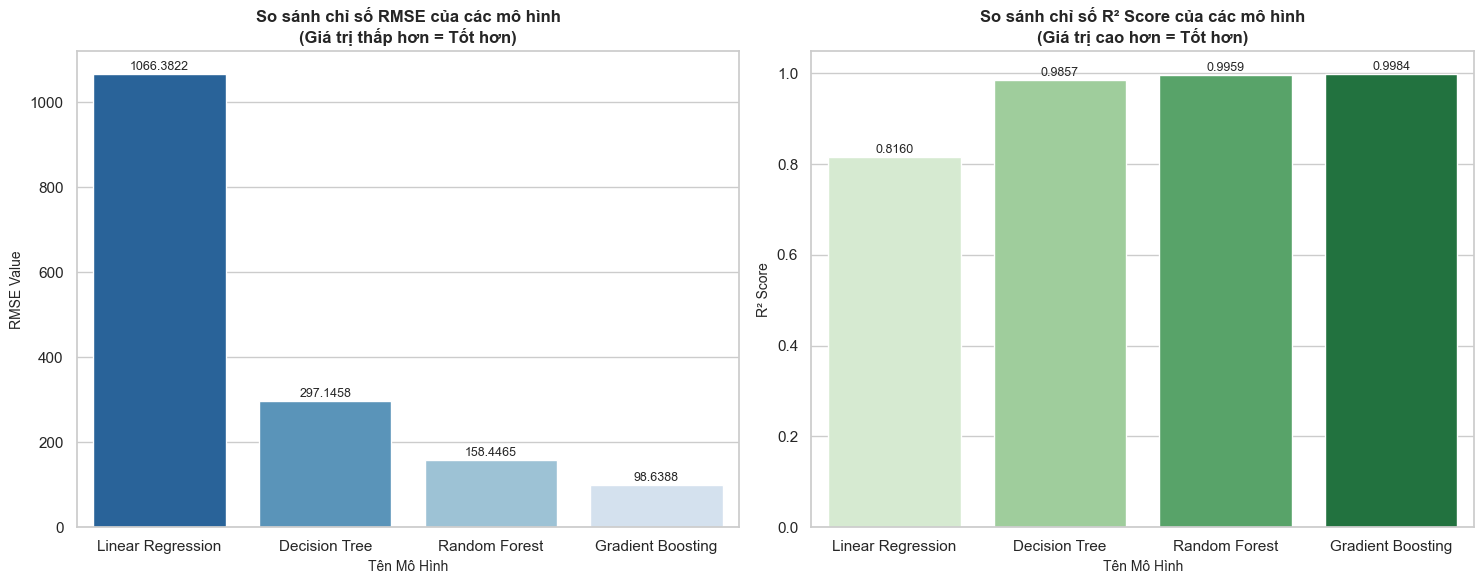

🏆 KẾT LUẬN SƠ BỘ: Thuật toán có hiệu suất tổng thể tốt nhất là 'Gradient Boosting'
-> Đạt chỉ số R² Score cao nhất: 0.9984
-> Đạt chỉ số sai số RMSE thấp nhất: 98.6388


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện đồ họa cho biểu đồ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Vẽ biểu đồ so sánh chỉ số RMSE (Càng thấp càng tốt)
sns.barplot(x="Model Name", y="RMSE", data=df_eval, ax=axes[0], palette="Blues_r")
axes[0].set_title("So sánh chỉ số RMSE của các mô hình\n(Giá trị thấp hơn = Tốt hơn)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Tên Mô Hình", fontsize=10)
axes[0].set_ylabel("RMSE Value", fontsize=10)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

# 2. Vẽ biểu đồ so sánh chỉ số R2 Score (Càng cao càng tốt)
sns.barplot(x="Model Name", y="R2 Score", data=df_eval, ax=axes[1], palette="Greens")
axes[1].set_title("So sánh chỉ số R² Score của các mô hình\n(Giá trị cao hơn = Tốt hơn)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Tên Mô Hình", fontsize=10)
axes[1].set_ylabel("R² Score", fontsize=10)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

# 3. Tự động tìm ra mô hình có R2 Score cao nhất để đưa ra gợi ý kết luận
best_model_row = df_eval.loc[df_eval['R2 Score'].idxmax()]
print("=========================================================================")
print(f"🏆 KẾT LUẬN SƠ BỘ: Thuật toán có hiệu suất tổng thể tốt nhất là '{best_model_row['Model Name']}'")
print(f"-> Đạt chỉ số R² Score cao nhất: {best_model_row['R2 Score']:.4f}")
print(f"-> Đạt chỉ số sai số RMSE thấp nhất: {best_model_row['RMSE']:.4f}")

## 8. Model Saving (Lưu trữ mô hình tối ưu)
* **Mục tiêu:** Đóng gói và lưu trữ vật lý mô hình có hiệu suất cao nhất dưới định dạng file nhị phân `.pkl` (Pickle).
* **Tên file lưu trữ:** `sales_model.pkl`
* **Lợi ích:** * Giúp triển khai mô hình vào môi trường thực tế (Production) hoặc tích hợp vào các ứng dụng web/API.
  * Cho phép tái sử dụng để dự đoán doanh số cho các đơn hàng mới trong tương lai ngay lập tức mà không cần tốn thời gian và tài nguyên máy tính để huấn luyện lại từ đầu.

In [ ]:
import joblib
import os

# 1. Định nghĩa từ điển liên kết giữa tên mô hình và thực thể mô hình đã huấn luyện ở Mục 4
trained_models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

# 2. Xác định tên mô hình xuất sắc nhất từ bước tính toán trước
# (best_model_row đã được khai báo ở mục 7)
best_model_name = best_model_row['Model Name']
best_model_object = trained_models[best_model_name]

# 3. Định nghĩa đường dẫn và thư mục lưu trữ mô hình
model_dir = 'models/'
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, 'sales_model.pkl')

# 4. Tiến hành lưu trữ mô hình đóng gói (.pkl)
joblib.dump(best_model_object, model_path)

print("=== BÁO CÁO LƯU TRỮ MÔ HÌNH (MODEL SAVING) ===")
print(f"🏆 Mô hình được chọn để lưu trữ: '{best_model_name}'")
print(f"✅ Đã đóng gói và xuất file thành công tại: '{model_path}'")
print(f"Kích thước file mô hình trên đĩa: {os.path.getsize(model_path) / 1024:.2f} KB")

=== BÁO CÁO LƯU TRỮ MÔ HÌNH (MODEL SAVING) ===
🏆 Mô hình được chọn để lưu trữ: 'Gradient Boosting'
✅ Đã đóng gói và xuất file thành công tại: 'models/sales_model.pkl'
Kích thước file mô hình trên đĩa: 140.38 KB


## Expected Output

Sau khi hoàn thành trọn vẹn chương **Machine Learning Modeling**:
1. **Model Training:** Nhiều thuật toán Hồi quy giám sát từ cơ bản đến nâng cao (`Linear Regression`, `Decision Tree`, `Random Forest`, `Gradient Boosting`) đã được huấn luyện thành công trên tập dữ liệu 80% (`X_train`, `y_train`).
2. **Model Prediction:** Các mô hình đã hoàn thành bài kiểm tra năng lực, xuất ra các mảng kết quả dự đoán giá trị doanh số trên tập kiểm thử độc lập 20% (`X_test`).
3. **Model Evaluation:** Hiệu suất dự đoán của từng thuật toán được đo lường, bóc tách tường minh qua bộ 4 chỉ số chuẩn mực toán học: `MAE`, `MSE`, `RMSE`, và `R² Score`.
4. **Model Comparison:** Trực quan hóa thành công biểu đồ so sánh hiệu suất, tạo cơ sở logic vững chắc để tìm ra thuật toán tối ưu, có khả năng tổng quát hóa dữ liệu tốt nhất.
5. **Model Saving:** "Nhà vô địch" đã được đóng gói an toàn vào file cấu trúc `models/sales_model.pkl`, hoàn tất chu trình xây dựng ứng dụng Học máy và sẵn sàng cho các bài toán dự báo thực tế trong tương lai.